# Compare non-overlapping test results: GRU last-state, LSTM all-states, MLP, and TCN

This notebook compares the selected model variants for the follow-up evaluation:

- **GRU**: last hidden state version from `results_nonoverlap/`
- **LSTM**: all hidden states version from `results_allstates/`
- **MLP**: direct MLP version from `results_nonoverlap/`
- **TCN**: direct TCN version from `results_nonoverlap/`

The comparison focuses on the **non-overlapping test-block evaluation** using `test_stride = H = 50`.

Outputs are saved to:

```text
../results_selected_nonoverlap/
../figures_selected_nonoverlap/
```



In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RESULTS_NONOVERLAP = Path("../results_nonoverlap")
RESULTS_ALLSTATES = Path("../results_allstates")

OUTPUT_RESULTS_DIR = Path("../results_selected_nonoverlap")
OUTPUT_FIGURES_DIR = Path("../figures_selected_nonoverlap")
OUTPUT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("results_nonoverlap exists:", RESULTS_NONOVERLAP.exists(), RESULTS_NONOVERLAP.resolve())
print("results_allstates exists:", RESULTS_ALLSTATES.exists(), RESULTS_ALLSTATES.resolve())
print("output results:", OUTPUT_RESULTS_DIR.resolve())
print("output figures:", OUTPUT_FIGURES_DIR.resolve())

results_nonoverlap exists: True /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_nonoverlap
results_allstates exists: True /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates
output results: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap
output figures: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap


## 1. Helper functions

In [2]:
def add_metadata(df, architecture, feature_set, state_usage, eval_type, source_file):
    df = df.copy()
    df["architecture"] = architecture
    df["feature_set"] = feature_set
    df["state_usage"] = state_usage
    df["eval_type"] = eval_type
    df["source_file"] = str(source_file)
    return df


def safe_name(text):
    return (
        str(text)
        .replace(" ", "_")
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_per_")
        .replace(".", "")
        .replace("(", "")
        .replace(")", "")
    )


def model_label(row):
    arch = row["architecture"]
    fs = row["feature_set"]
    state = row["state_usage"]
    if arch in ["GRU", "LSTM"]:
        return f"{arch} {state.replace('_', '-')} {fs}"
    return f"{arch} {fs}"

## 2. Load selected non-overlapping test metrics

This cell loads:

- GRU last-state non-overlap metrics from `results_nonoverlap/`
- LSTM all-states non-overlap metrics from `results_allstates/`
- MLP non-overlap metrics from `results_nonoverlap/`
- TCN non-overlap metrics from `results_nonoverlap/`


In [3]:
rows = []
feature_sets = ["baseline", "physics"]

selected_specs = [
    {
        "architecture": "GRU",
        "state_usage": "last_state",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "gru_direct_{feature}_L50_H50_S5_nonoverlap_test_metrics.csv",
    },
    {
        "architecture": "LSTM",
        "state_usage": "all_states",
        "dir": RESULTS_ALLSTATES,
        "pattern": "lstm_allstates_{feature}_L50_H50_S5_nonoverlap_test_metrics.csv",
    },
    {
        "architecture": "MLP",
        "state_usage": "direct",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "mlp_direct_{feature}_L50_H50_S5_nonoverlap_test_metrics.csv",
    },
    {
        "architecture": "TCN",
        "state_usage": "direct",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "tcn_direct_{feature}_L50_H50_S5_nonoverlap_test_metrics.csv",
    },
]

missing_files = []
for spec in selected_specs:
    for feature in feature_sets:
        path = spec["dir"] / spec["pattern"].format(feature=feature)
        if not path.exists():
            missing_files.append(str(path))
            continue
        df = pd.read_csv(path)
        df = add_metadata(
            df,
            architecture=spec["architecture"],
            feature_set=feature,
            state_usage=spec["state_usage"],
            eval_type="nonoverlap_test",
            source_file=path,
        )
        rows.append(df)

if missing_files:
    print("Missing files:")
    for item in missing_files:
        print(" -", item)

if not rows:
    raise RuntimeError("No metric files were loaded. Check folder paths and filenames.")

metrics_df = pd.concat(rows, ignore_index=True)
metrics_path = OUTPUT_RESULTS_DIR / "selected_models_nonoverlap_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path.resolve())
metrics_df.head(12)

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_nonoverlap_metrics.csv


,split,output,MSE,RMSE,MAE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2,true_mean_abs,true_std,architecture,feature_set,state_usage,eval_type,source_file
0,test_nonoverlap_stride50,SEI growth rate [nm/s],4.211772e-07,0.000649,0.000363,0.170151,0.304210,0.148661,0.907456,0.002442,0.002133,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...
1,test_nonoverlap_stride50,Negative SEI thickness [nm],2.681404e+03,51.782272,30.597267,0.342076,0.578924,0.202868,0.664847,150.823290,89.445720,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...
2,test_nonoverlap_stride50,Cell temperature [K],1.354873e-02,0.116399,0.060674,0.137844,0.264444,0.000204,0.930069,298.104520,0.440165,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...
3,test_nonoverlap_stride50,SEI growth rate [nm/s],3.526369e-07,0.000594,0.000223,0.104473,0.278359,0.091278,0.922516,0.002442,0.002133,GRU,physics,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_physics_L50_H...
4,test_nonoverlap_stride50,Negative SEI thickness [nm],5.261190e+02,22.937284,13.934503,0.155787,0.256438,0.092390,0.934240,150.823290,89.445720,GRU,physics,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_physics_L50_H...
5,test_nonoverlap_stride50,Cell temperature [K],8.845089e-03,0.094048,0.033667,0.076488,0.213666,0.000113,0.954347,298.104520,0.440165,GRU,physics,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_physics_L50_H...
6,test_nonoverlap_stride50,SEI growth rate [nm/s],4.779364e-07,0.000691,0.000388,0.181953,0.324060,0.158972,0.894985,0.002442,0.002133,LSTM,baseline,all_states,nonoverlap_test,../results_allstates/lstm_allstates_baseline_L...
7,test_nonoverlap_stride50,Negative SEI thickness [nm],2.228562e+03,47.207650,27.523989,0.307717,0.527780,0.182492,0.721448,150.823290,89.445720,LSTM,baseline,all_states,nonoverlap_test,../results_allstates/lstm_allstates_baseline_L...
8,test_nonoverlap_stride50,Cell temperature [K],2.746946e-02,0.165739,0.075105,0.170630,0.376538,0.000252,0.858219,298.104520,0.440165,LSTM,baseline,all_states,nonoverlap_test,../results_allstates/lstm_allstates_baseline_L...
9,test_nonoverlap_stride50,SEI growth rate [nm/s],1.413485e-07,0.000376,0.000185,0.086921,0.176233,0.075943,0.968942,0.002442,0.002133,LSTM,physics,all_states,nonoverlap_test,../results_allstates/lstm_allstates_physics_L5...


## 3. Main summary: mean NMAE and mean R²

This summary averages the three target outputs which can be used as a compact overview.


In [4]:
summary_df = (
    metrics_df
    .groupby(["architecture", "feature_set", "state_usage"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_NMAE_std=("NMAE_std", "mean"),
        mean_NRMSE_std=("NRMSE_std", "mean"),
        mean_R2=("R2", "mean"),
    )
)

summary_df["model"] = summary_df.apply(model_label, axis=1)
summary_df = summary_df.sort_values("mean_NMAE_std").reset_index(drop=True)

summary_path = OUTPUT_RESULTS_DIR / "selected_models_nonoverlap_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path.resolve())
summary_df

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_nonoverlap_summary.csv


,architecture,feature_set,state_usage,mean_MAE,mean_NMAE_std,mean_NRMSE_std,mean_R2,model
0,MLP,physics,direct,4.124245,0.106401,0.204182,0.957617,MLP physics
1,GRU,physics,last_state,4.656131,0.112249,0.249488,0.937034,GRU last-state physics
2,LSTM,physics,all_states,5.442060,0.112616,0.223714,0.948460,LSTM all-states physics
3,TCN,physics,direct,5.348957,0.128821,0.288167,0.916366,TCN physics
4,TCN,baseline,direct,10.229610,0.195492,0.364975,0.842519,TCN baseline
5,MLP,baseline,direct,10.351795,0.201555,0.331287,0.874296,MLP baseline
6,GRU,baseline,last_state,10.219435,0.216690,0.382526,0.834124,GRU last-state baseline
7,LSTM,baseline,all_states,9.199828,0.220100,0.409460,0.824884,LSTM all-states baseline


## 4. Output-specific table

This table is usually the most useful one for interpretation because it keeps SEI growth rate, SEI thickness, and temperature separate.


In [5]:
output_table = metrics_df.copy()
output_table["model"] = output_table.apply(model_label, axis=1)
output_table = output_table[[
    "model", "architecture", "feature_set", "state_usage", "output",
    "MAE", "RMSE", "NMAE_std", "NRMSE_std", "Relative_MAE_mean_abs", "R2"
]].sort_values(["output", "NMAE_std"])

output_table_path = OUTPUT_RESULTS_DIR / "selected_models_nonoverlap_output_table.csv"
output_table.to_csv(output_table_path, index=False)
print("Saved:", output_table_path.resolve())
output_table

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_nonoverlap_output_table.csv


,model,architecture,feature_set,state_usage,output,MAE,RMSE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2
11,LSTM all-states physics,LSTM,physics,all_states,Cell temperature [K],0.030258,0.098623,0.068742,0.224058,0.000102,0.949798
5,GRU last-state physics,GRU,physics,last_state,Cell temperature [K],0.033667,0.094048,0.076488,0.213666,0.000113,0.954347
17,MLP physics,MLP,physics,direct,Cell temperature [K],0.037924,0.103417,0.086159,0.234950,0.000127,0.944798
23,TCN physics,TCN,physics,direct,Cell temperature [K],0.040803,0.123497,0.092700,0.280569,0.000137,0.921281
20,TCN baseline,TCN,baseline,direct,Cell temperature [K],0.043060,0.108541,0.097827,0.246591,0.000144,0.939193
14,MLP baseline,MLP,baseline,direct,Cell temperature [K],0.044064,0.104004,0.100108,0.236283,0.000148,0.944170
2,GRU last-state baseline,GRU,baseline,last_state,Cell temperature [K],0.060674,0.116399,0.137844,0.264444,0.000204,0.930069
8,LSTM all-states baseline,LSTM,baseline,all_states,Cell temperature [K],0.075105,0.165739,0.170630,0.376538,0.000252,0.858219
16,MLP physics,MLP,physics,direct,Negative SEI thickness [nm],12.334608,18.510275,0.137900,0.206944,0.081782,0.957174
4,GRU last-state physics,GRU,physics,last_state,Negative SEI thickness [nm],13.934503,22.937284,0.155787,0.256438,0.092390,0.934240


## 5. Best model by output using NMAE

In [6]:
best_by_output = (
    output_table
    .sort_values("NMAE_std")
    .groupby("output", as_index=False)
    .first()
)

best_path = OUTPUT_RESULTS_DIR / "selected_models_best_by_output_nmae.csv"
best_by_output.to_csv(best_path, index=False)
print("Saved:", best_path.resolve())
best_by_output[["output", "model", "NMAE_std", "MAE", "R2"]]

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_best_by_output_nmae.csv


,output,model,NMAE_std,MAE,R2
0,Cell temperature [K],LSTM all-states physics,0.068742,0.030258,0.949798
1,Negative SEI thickness [nm],MLP physics,0.137900,12.334608,0.957174
2,SEI growth rate [nm/s],LSTM all-states physics,0.086921,0.000185,0.968942


## 6. Physics improvement over baseline

This compares baseline vs physics features within each selected architecture/state choice.


In [7]:
pivot = summary_df.pivot_table(
    index=["architecture", "state_usage"],
    columns="feature_set",
    values=["mean_NMAE_std", "mean_R2"]
).reset_index()

pivot.columns = ["_".join([str(x) for x in col if x]) for col in pivot.columns]

if "mean_NMAE_std_baseline" in pivot.columns and "mean_NMAE_std_physics" in pivot.columns:
    pivot["NMAE_reduction_physics_vs_baseline_percent"] = (
        100 * (pivot["mean_NMAE_std_baseline"] - pivot["mean_NMAE_std_physics"]) / pivot["mean_NMAE_std_baseline"]
    )

if "mean_R2_baseline" in pivot.columns and "mean_R2_physics" in pivot.columns:
    pivot["R2_gain_physics_minus_baseline"] = pivot["mean_R2_physics"] - pivot["mean_R2_baseline"]

improvement_path = OUTPUT_RESULTS_DIR / "selected_models_physics_improvement_summary.csv"
pivot.to_csv(improvement_path, index=False)
print("Saved:", improvement_path.resolve())
pivot

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_physics_improvement_summary.csv


,architecture,state_usage,mean_NMAE_std_baseline,mean_NMAE_std_physics,mean_R2_baseline,mean_R2_physics,NMAE_reduction_physics_vs_baseline_percent,R2_gain_physics_minus_baseline
0,GRU,last_state,0.216690,0.112249,0.834124,0.937034,48.198338,0.102910
1,LSTM,all_states,0.220100,0.112616,0.824884,0.948460,48.834136,0.123576
2,MLP,direct,0.201555,0.106401,0.874296,0.957617,47.210213,0.083321
3,TCN,direct,0.195492,0.128821,0.842519,0.916366,34.104127,0.073847


## 7. Plots: mean NMAE and mean R²

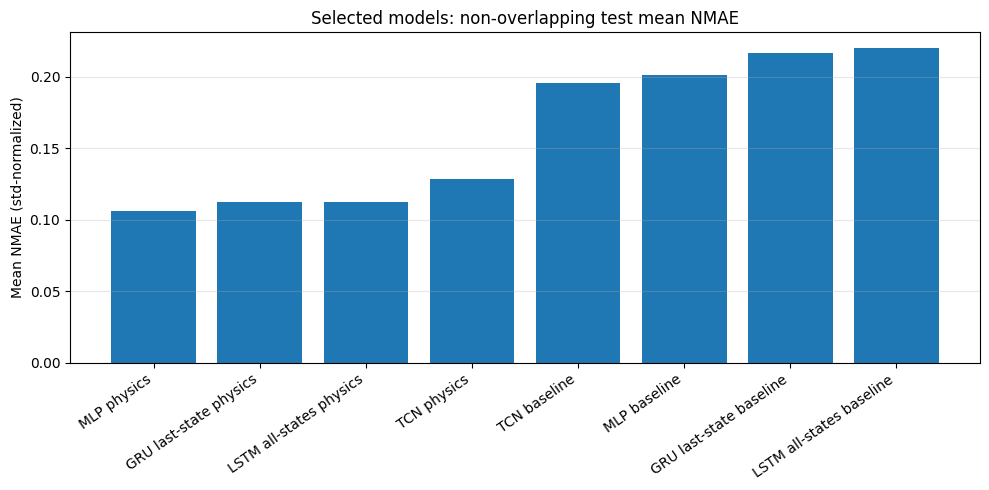

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_mean_nmae.png


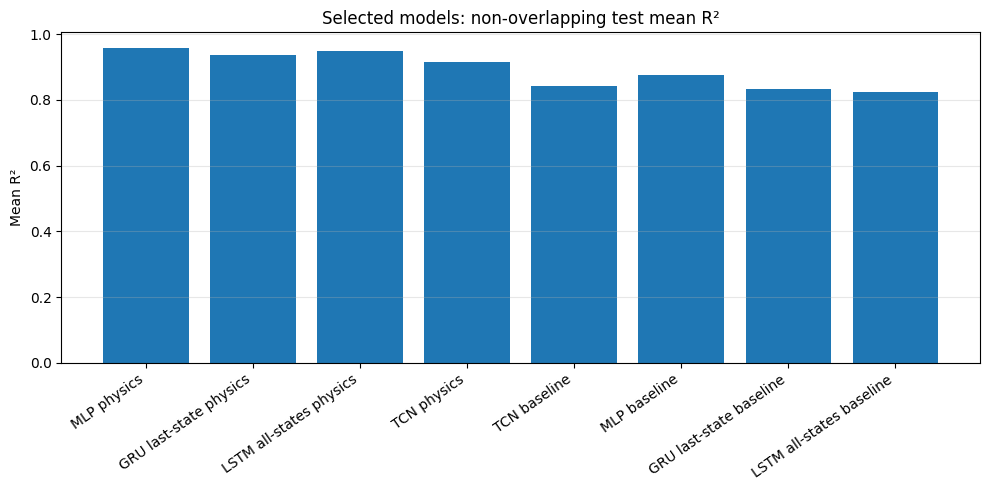

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_mean_r2.png


In [8]:
plot_df = summary_df.sort_values("mean_NMAE_std", ascending=True).copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["mean_NMAE_std"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Mean NMAE (std-normalized)")
plt.title("Selected models: non-overlapping test mean NMAE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = OUTPUT_FIGURES_DIR / "selected_models_nonoverlap_mean_nmae.png"
plt.savefig(fig_path, dpi=250)
plt.show()
print("Saved:", fig_path.resolve())

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["mean_R2"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Mean R²")
plt.title("Selected models: non-overlapping test mean R²")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = OUTPUT_FIGURES_DIR / "selected_models_nonoverlap_mean_r2.png"
plt.savefig(fig_path, dpi=250)
plt.show()
print("Saved:", fig_path.resolve())

## 8. Plots: output-specific NMAE and R²

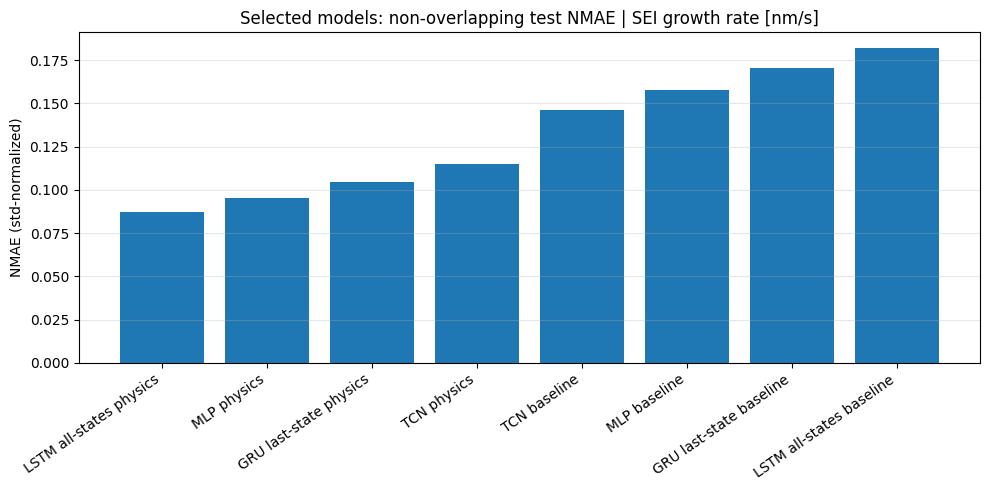

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_nmae_SEI_growth_rate_nm_per_s.png


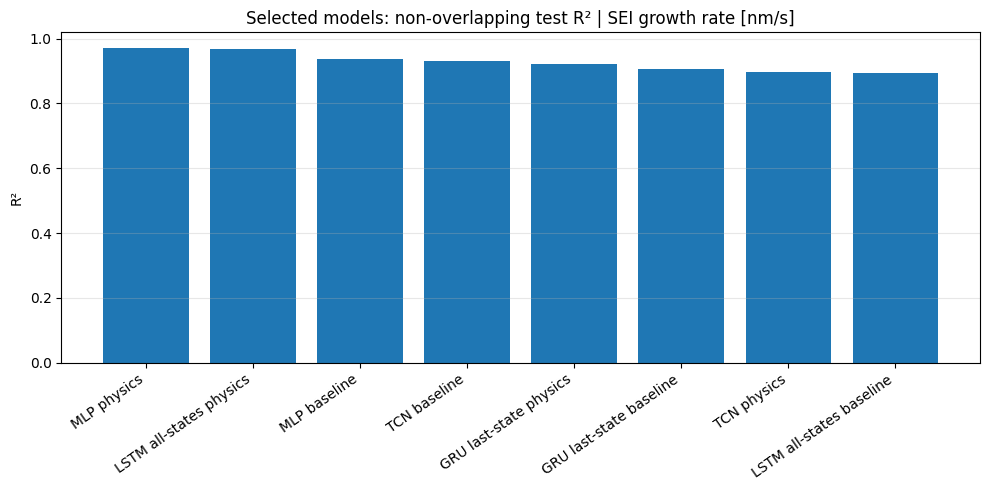

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_r2_SEI_growth_rate_nm_per_s.png


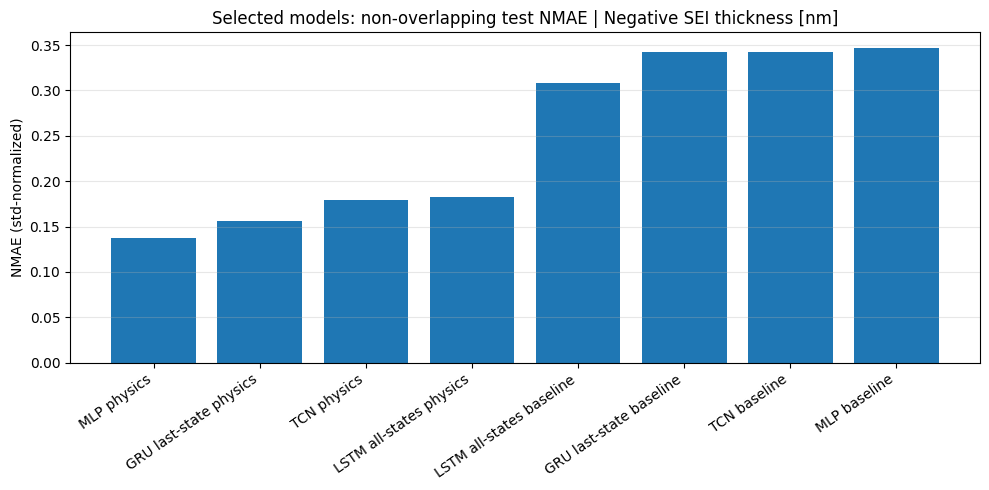

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_nmae_Negative_SEI_thickness_nm.png


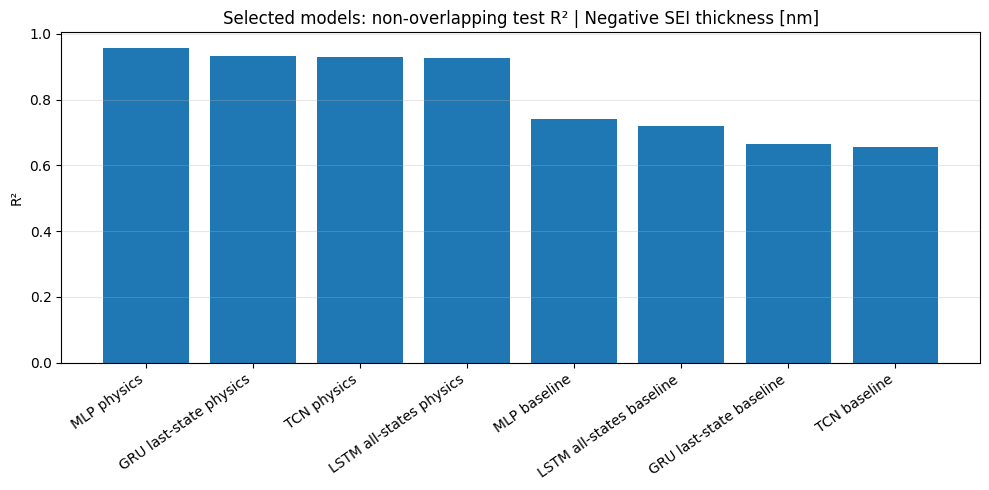

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_r2_Negative_SEI_thickness_nm.png


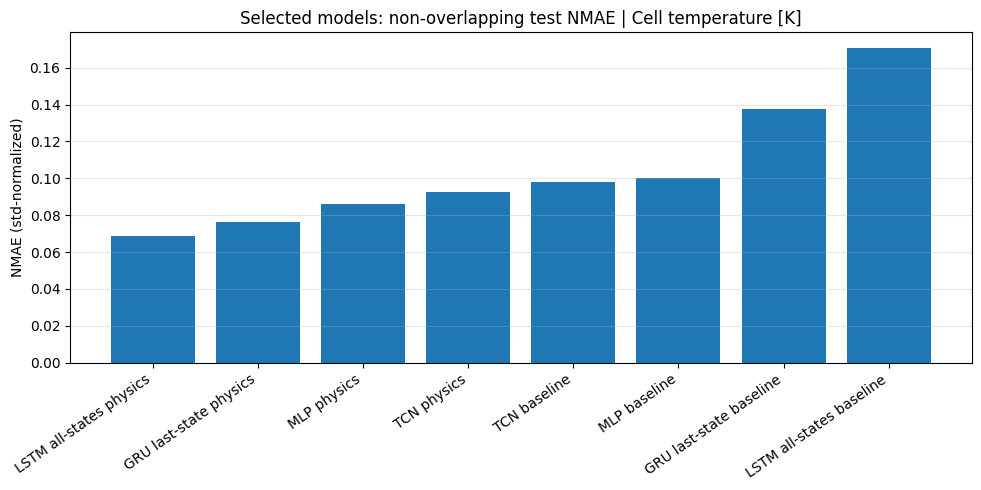

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_nmae_Cell_temperature_K.png


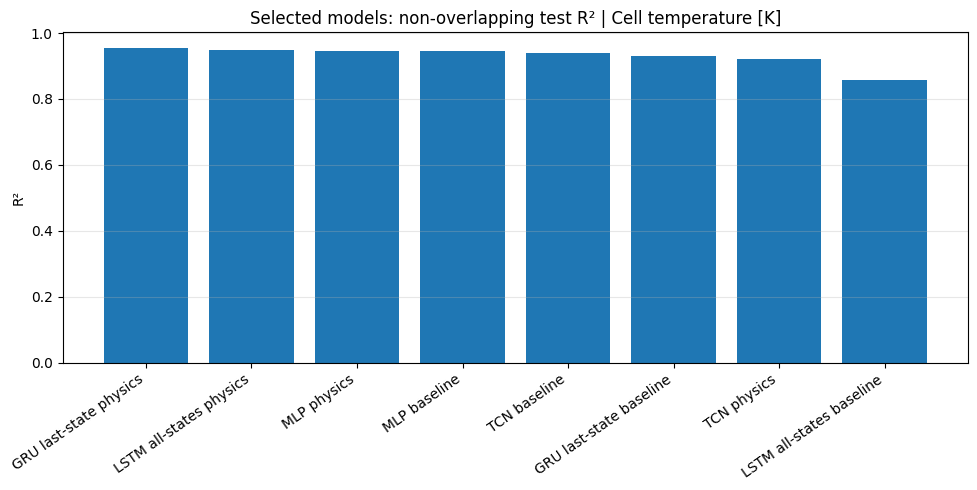

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_nonoverlap_r2_Cell_temperature_K.png


In [9]:
for output_name in metrics_df["output"].unique():
    temp = output_table[output_table["output"] == output_name].sort_values("NMAE_std", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.bar(temp["model"], temp["NMAE_std"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("NMAE (std-normalized)")
    plt.title(f"Selected models: non-overlapping test NMAE | {output_name}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUT_FIGURES_DIR / f"selected_models_nonoverlap_nmae_{safe_name(output_name)}.png"
    plt.savefig(fig_path, dpi=250)
    plt.show()
    print("Saved:", fig_path.resolve())

    temp_r2 = output_table[output_table["output"] == output_name].sort_values("R2", ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(temp_r2["model"], temp_r2["R2"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("R²")
    plt.title(f"Selected models: non-overlapping test R² | {output_name}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUT_FIGURES_DIR / f"selected_models_nonoverlap_r2_{safe_name(output_name)}.png"
    plt.savefig(fig_path, dpi=250)
    plt.show()
    print("Saved:", fig_path.resolve())

## 9. Load and compare physical violations

This section checks negative predictions for SEI growth rate, SEI thickness, and cell temperature in Kelvin.


In [10]:
violation_rows = []
missing_violation_files = []

violation_specs = [
    {
        "architecture": "GRU",
        "state_usage": "last_state",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "gru_direct_{feature}_L50_H50_S5_nonoverlap_physical_violations.csv",
    },
    {
        "architecture": "LSTM",
        "state_usage": "all_states",
        "dir": RESULTS_ALLSTATES,
        "pattern": "lstm_allstates_{feature}_L50_H50_S5_nonoverlap_physical_violations.csv",
    },
    {
        "architecture": "MLP",
        "state_usage": "direct",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "mlp_direct_{feature}_L50_H50_S5_nonoverlap_physical_violations.csv",
    },
    {
        "architecture": "TCN",
        "state_usage": "direct",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "tcn_direct_{feature}_L50_H50_S5_nonoverlap_physical_violations.csv",
    },
]

for spec in violation_specs:
    for feature in feature_sets:
        path = spec["dir"] / spec["pattern"].format(feature=feature)
        if not path.exists():
            missing_violation_files.append(str(path))
            continue
        df = pd.read_csv(path)
        df = add_metadata(
            df,
            architecture=spec["architecture"],
            feature_set=feature,
            state_usage=spec["state_usage"],
            eval_type="nonoverlap_test",
            source_file=path,
        )
        violation_rows.append(df)

if missing_violation_files:
    print("Missing physical violation files:")
    for item in missing_violation_files:
        print(" -", item)

if violation_rows:
    violations_df = pd.concat(violation_rows, ignore_index=True)
    violations_df["model"] = violations_df.apply(model_label, axis=1)
    violations_path = OUTPUT_RESULTS_DIR / "selected_models_nonoverlap_physical_violations.csv"
    violations_df.to_csv(violations_path, index=False)
    print("Saved:", violations_path.resolve())
    display(violations_df[["model", "output", "negative_count", "total_count", "negative_percent", "minimum_prediction"]])
else:
    print("No physical violation files were loaded.")

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_nonoverlap_physical_violations.csv


,model,output,negative_count,total_count,negative_percent,minimum_prediction
0,GRU last-state baseline,SEI growth rate [nm/s],1160,245200,0.473083,-0.000560
1,GRU last-state baseline,Negative SEI thickness [nm],27286,245200,11.128059,-12.097260
2,GRU last-state baseline,Cell temperature [K],0,245200,0.000000,295.634552
3,GRU last-state physics,SEI growth rate [nm/s],14452,245200,5.893964,-0.000290
4,GRU last-state physics,Negative SEI thickness [nm],800,245200,0.326264,-7.655853
5,GRU last-state physics,Cell temperature [K],0,245200,0.000000,295.464081
6,LSTM all-states baseline,SEI growth rate [nm/s],36024,245200,14.691680,-0.001083
7,LSTM all-states baseline,Negative SEI thickness [nm],527,245200,0.214927,-8.595673
8,LSTM all-states baseline,Cell temperature [K],0,245200,0.000000,295.817352
9,LSTM all-states physics,SEI growth rate [nm/s],4784,245200,1.951060,-0.002895


## 10. Plot physical violation percentages

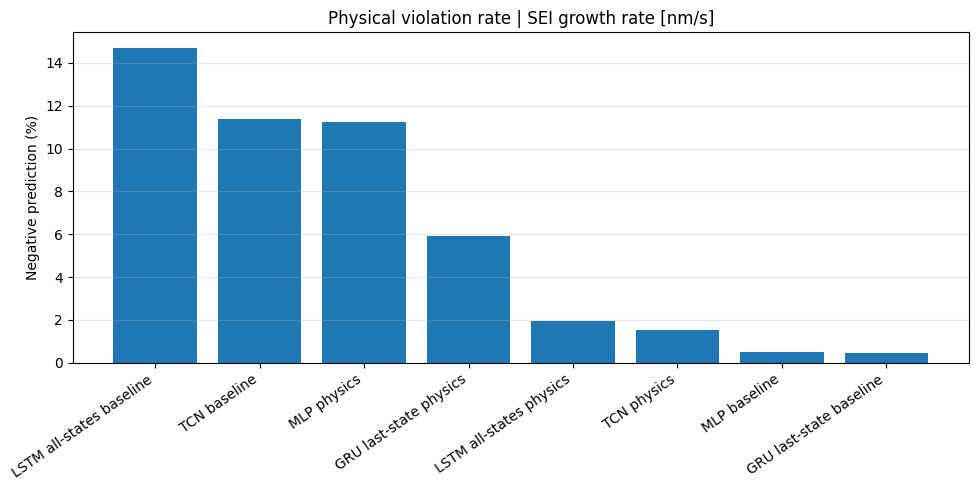

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_violation_percent_SEI_growth_rate_nm_per_s.png


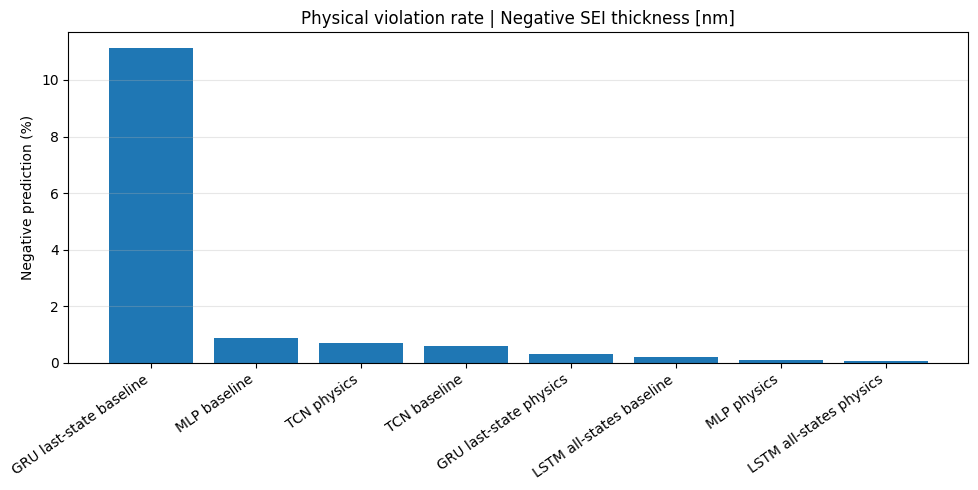

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_violation_percent_Negative_SEI_thickness_nm.png


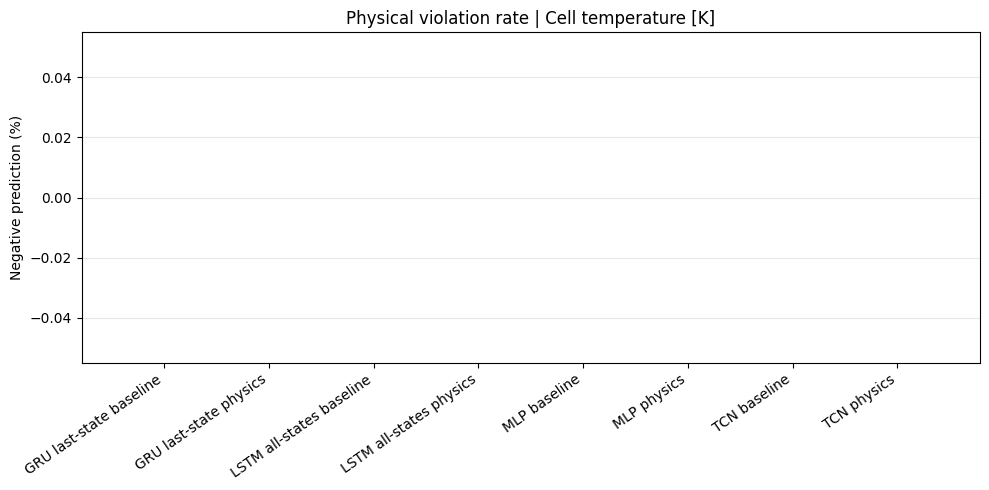

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_violation_percent_Cell_temperature_K.png


In [11]:
if "violations_df" in globals() and not violations_df.empty:
    for output_name in violations_df["output"].unique():
        temp = violations_df[violations_df["output"] == output_name].copy()
        temp = temp.sort_values("negative_percent", ascending=False)

        plt.figure(figsize=(10, 5))
        plt.bar(temp["model"], temp["negative_percent"])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Negative prediction (%)")
        plt.title(f"Physical violation rate | {output_name}")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        fig_path = OUTPUT_FIGURES_DIR / f"selected_models_violation_percent_{safe_name(output_name)}.png"
        plt.savefig(fig_path, dpi=250)
        plt.show()
        print("Saved:", fig_path.resolve())
else:
    print("Skipping violation plots because violations_df is empty.")

## 11. Horizon-wise NMAE comparison

This compares how normalized error changes across the 50 future prediction steps.


In [12]:
horizon_rows = []
missing_horizon_files = []

horizon_specs = [
    {
        "architecture": "GRU",
        "state_usage": "last_state",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "gru_direct_{feature}_L50_H50_S5_nonoverlap_horizon_nmae.csv",
    },
    {
        "architecture": "LSTM",
        "state_usage": "all_states",
        "dir": RESULTS_ALLSTATES,
        "pattern": "lstm_allstates_{feature}_L50_H50_S5_nonoverlap_horizon_nmae.csv",
    },
    {
        "architecture": "MLP",
        "state_usage": "direct",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "mlp_direct_{feature}_L50_H50_S5_nonoverlap_horizon_nmae.csv",
    },
    {
        "architecture": "TCN",
        "state_usage": "direct",
        "dir": RESULTS_NONOVERLAP,
        "pattern": "tcn_direct_{feature}_L50_H50_S5_nonoverlap_horizon_nmae.csv",
    },
]

for spec in horizon_specs:
    for feature in feature_sets:
        path = spec["dir"] / spec["pattern"].format(feature=feature)
        if not path.exists():
            missing_horizon_files.append(str(path))
            continue
        df = pd.read_csv(path)
        df = add_metadata(
            df,
            architecture=spec["architecture"],
            feature_set=feature,
            state_usage=spec["state_usage"],
            eval_type="nonoverlap_test",
            source_file=path,
        )
        df["model"] = df.apply(model_label, axis=1)
        horizon_rows.append(df)

if missing_horizon_files:
    print("Missing horizon NMAE files:")
    for item in missing_horizon_files:
        print(" -", item)

if horizon_rows:
    horizon_df = pd.concat(horizon_rows, ignore_index=True)
    horizon_path = OUTPUT_RESULTS_DIR / "selected_models_nonoverlap_horizon_nmae.csv"
    horizon_df.to_csv(horizon_path, index=False)
    print("Saved:", horizon_path.resolve())
    display(horizon_df.head())
else:
    print("No horizon NMAE files were loaded.")

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_selected_nonoverlap/selected_models_nonoverlap_horizon_nmae.csv


,horizon_step,output,NMAE_std,architecture,feature_set,state_usage,eval_type,source_file,model
0,1,SEI growth rate [nm/s],0.169785,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...,GRU last-state baseline
1,2,SEI growth rate [nm/s],0.169607,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...,GRU last-state baseline
2,3,SEI growth rate [nm/s],0.169887,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...,GRU last-state baseline
3,4,SEI growth rate [nm/s],0.169984,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...,GRU last-state baseline
4,5,SEI growth rate [nm/s],0.169671,GRU,baseline,last_state,nonoverlap_test,../results_nonoverlap/gru_direct_baseline_L50_...,GRU last-state baseline


## 12. Plot horizon-wise NMAE

One plot is created per target output. For clarity, baseline and physics are separated into different figures.


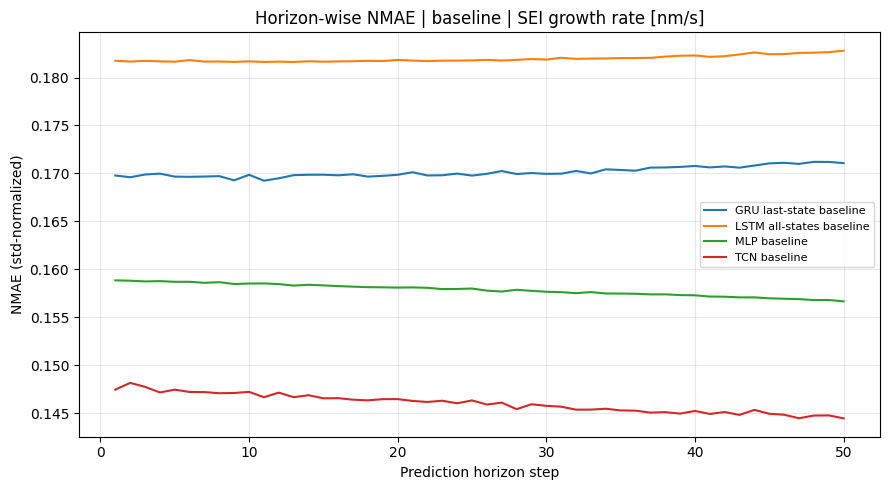

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_horizon_nmae_baseline_SEI_growth_rate_nm_per_s.png


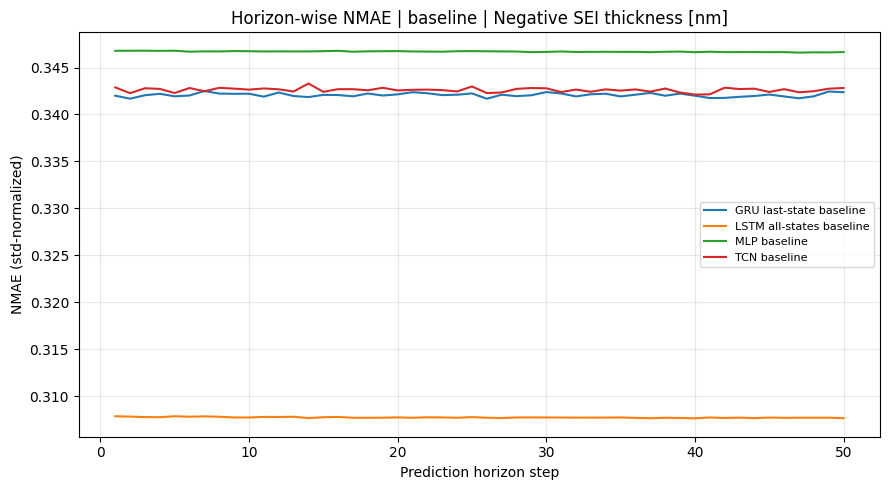

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_horizon_nmae_baseline_Negative_SEI_thickness_nm.png


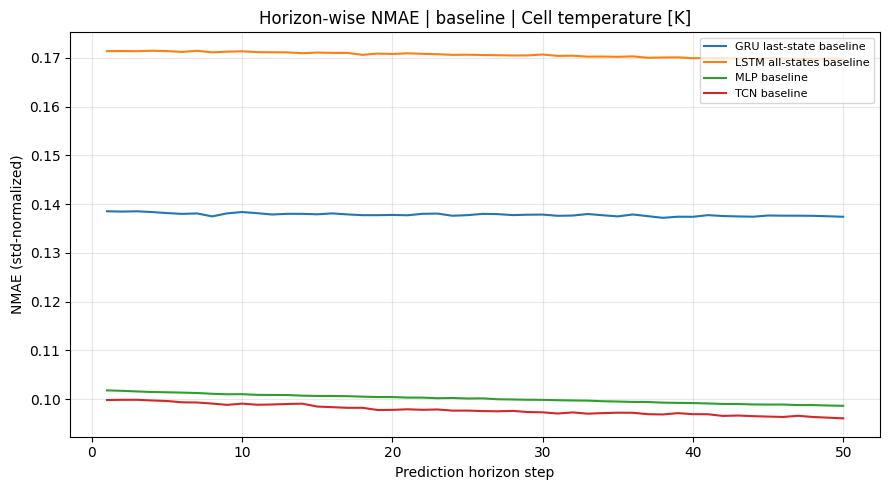

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_horizon_nmae_baseline_Cell_temperature_K.png


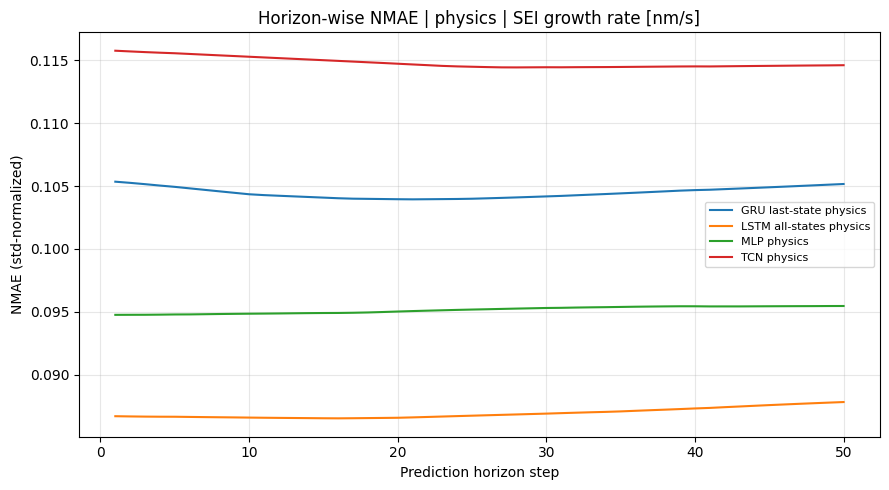

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_horizon_nmae_physics_SEI_growth_rate_nm_per_s.png


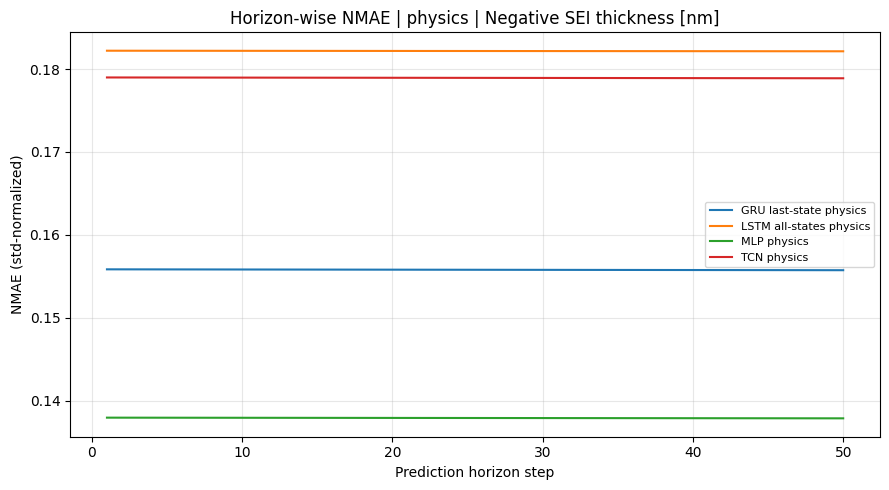

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_horizon_nmae_physics_Negative_SEI_thickness_nm.png


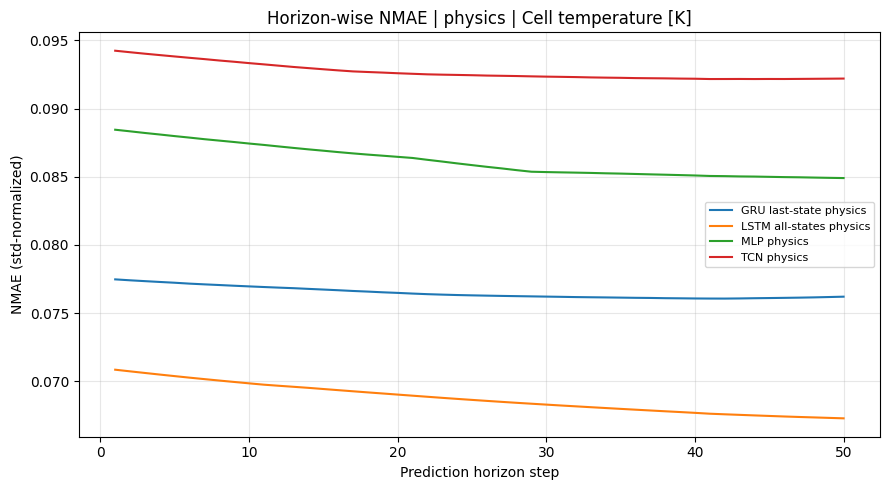

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_selected_nonoverlap/selected_models_horizon_nmae_physics_Cell_temperature_K.png


In [13]:
if "horizon_df" in globals() and not horizon_df.empty:
    for feature in feature_sets:
        feature_df = horizon_df[horizon_df["feature_set"] == feature]

        for output_name in feature_df["output"].unique():
            temp = feature_df[feature_df["output"] == output_name]

            plt.figure(figsize=(9, 5))
            for model in temp["model"].unique():
                model_df = temp[temp["model"] == model].sort_values("horizon_step")
                plt.plot(model_df["horizon_step"], model_df["NMAE_std"], label=model)

            plt.xlabel("Prediction horizon step")
            plt.ylabel("NMAE (std-normalized)")
            plt.title(f"Horizon-wise NMAE | {feature} | {output_name}")
            plt.legend(fontsize=8)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            fig_path = OUTPUT_FIGURES_DIR / f"selected_models_horizon_nmae_{feature}_{safe_name(output_name)}.png"
            plt.savefig(fig_path, dpi=250)
            plt.show()
            print("Saved:", fig_path.resolve())
else:
    print("Skipping horizon plots because horizon_df is empty.")

## 13. Suggested interpretation template

Use this after reviewing the numbers generated above.


In [14]:
best_overall = summary_df.iloc[0]
print("Best overall by mean NMAE:")
print(best_overall[["model", "mean_NMAE_std", "mean_R2"]])

print("
Text template:")
template = (
    "For the follow-up comparison, I compared the selected non-overlapping test results using "
    "GRU last-state, LSTM all-states, MLP, and TCN. The evaluation used test_stride = H = 50, "
    "so each forecast block covered a distinct future region without repeated overlap. Based on "
    "mean NMAE across the three targets, the best selected model was "
    f"{best_overall['model']} with mean NMAE = {best_overall['mean_NMAE_std']:.4f} "
    f"and mean R² = {best_overall['mean_R2']:.4f}. Output-specific results should still be "
    "inspected because SEI growth rate, SEI thickness, and temperature respond differently to "
    "the architecture and feature set."
)
print(template)

SyntaxError: unterminated string literal (detected at line 5) (2393563554.py, line 5)